# Module 1 — Language Detection
**RAG-Based E-commerce Customer Support Chatbot**

**Goal:** classify the language of an incoming customer message using a *traditional* NLP approach
(Count/TF-IDF Vectorizer + a linear classifier), so the system can:
1. Search the knowledge base in the right language.
2. Reply back to the customer in the same language they used.

**Dataset:** [`papluca/language-identification`](https://huggingface.co/datasets/papluca/language-identification)
— ~90k samples, 20 languages, already split into `train` / `validation` / `test`.


In [37]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)
else:
    print("GPU is NOT available")

GPU Available: True
GPU: NVIDIA GeForce MX350
CUDA Version: 12.1


In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


## 1. Setup

In [39]:
# Install once (uncomment if needed)
!pip install datasets scikit-learn pandas matplotlib seaborn joblib

import pandas as pd
import numpy as np
import re
import string
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 120)



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load the dataset

The dataset comes with pre-made `train`, `validation`, and `test` splits, so we don't need to split it ourselves.

In [40]:
dataset = load_dataset("papluca/language-identification")

train_df = dataset["train"].to_pandas()
val_df   = dataset["validation"].to_pandas()
test_df  = dataset["test"].to_pandas()

print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
train_df.head()


Train: (70000, 2) | Val: (10000, 2) | Test: (10000, 2)


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fo..."
1,bg,размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до около 100 km за...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把这段话复制走了，既能赚积分，还省事，走到哪复制到哪，最重要的是，不用认真的评论了，不用想还差多少字，直接发出就可以了，推荐给大家！！
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของเก่า ที่ ไม่ 29 สำหรับ เฟอร์นิเจอร์ และ เงิน ไท ร้อง บริษัท ที...
4,ru,Он увеличил давление .


## 3. Quick exploratory check

Before touching the text, we sanity-check:
- How many languages are there, and are the classes balanced?
- Any missing / empty text?
- Roughly how long are the messages (in characters)?


Number of languages: 20
labels
pt    3500
bg    3500
zh    3500
th    3500
ru    3500
pl    3500
ur    3500
sw    3500
tr    3500
es    3500
ar    3500
it    3500
hi    3500
de    3500
el    3500
nl    3500
fr    3500
vi    3500
en    3500
ja    3500
Name: count, dtype: int64


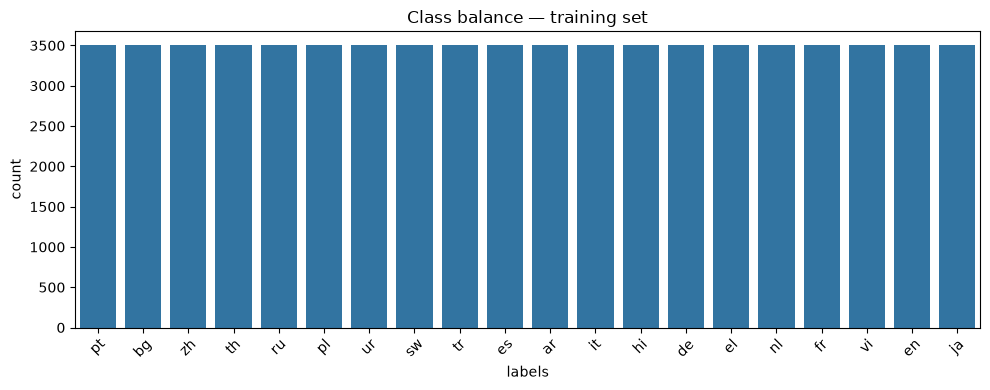

In [41]:
print("Number of languages:", train_df['labels'].nunique())
print(train_df['labels'].value_counts())

plt.figure(figsize=(10,4))
sns.countplot(data=train_df, x="labels", order=train_df['labels'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class balance — training set")
plt.tight_layout()
plt.show()


In [42]:
print("Missing text:", train_df['text'].isna().sum())
print("Empty strings:", (train_df['text'].str.strip() == "").sum())

train_df['char_len'] = train_df['text'].str.len()
train_df['char_len'].describe()


Missing text: 0
Empty strings: 0


count    70000.000000
mean       110.861414
std        103.106240
min          2.000000
25%         47.000000
50%         82.000000
75%        143.000000
max       2422.000000
Name: char_len, dtype: float64

## 4. Text preprocessing

For language identification specifically, the preprocessing has to be **lighter than usual**:
- We lowercase and strip URLs/emails/digits (they carry no language signal).
- We **do NOT remove punctuation or "stopwords"** the way we would for English sentiment/intent tasks —
  stopwords and diacritics/accented characters are actually one of the strongest signals of *which* language
  a sentence belongs to (e.g. "ñ", "ç", "ß", "ال", accented vowels in French/Spanish/Portuguese, etc.).
  Removing them would throw away the exact information the classifier depends on.


In [43]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URLs
    text = re.sub(r"\S+@\S+", " ", text)               # emails
    text = re.sub(r"\d+", " ", text)                    # digits (not language-specific)
    text = re.sub(r"\s+", " ", text).strip()            # collapse whitespace
    return text

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

train_df[["text", "clean_text", "labels"]].sample(5, random_state=RANDOM_STATE)


,text,clean_text,labels
46730,Hab für den Preis mehr erwartet.,hab für den preis mehr erwartet.,de
48393,"Письмо в письменном виде убийцы , друзья мои !","письмо в письменном виде убийцы , друзья мои !",ru
41416,जापानियों ने रैंकिंग दृश ् य और स ् थानों के पारंपरिक चीनी अभ ् यास को अपनाया है और korakian आधिकारिक रूप से जापान क...,जापानियों ने रैंकिंग दृश ् य और स ् थानों के पारंपरिक चीनी अभ ् यास को अपनाया है और korakian आधिकारिक रूप से जापान क...,hi
34506,"وفي عام 1853 , كان القصد من قصر دولما - bahce ( dolmabahce saraye ؛ dolmabahce caddesi , الهاتف 212 / 258-5544 ) هو ...","وفي عام , كان القصد من قصر دولما - bahce ( dolmabahce saraye ؛ dolmabahce caddesi , الهاتف / - ) هو بيان جريء من ايم...",ar
43725,"Các nhà chức trách y tế anh , trong 1995 nguyên tắc của họ ( lý luận uống rượu ) , nói rằng những người uống rất ít ...","các nhà chức trách y tế anh , trong nguyên tắc của họ ( lý luận uống rượu ) , nói rằng những người uống rất ít hoặc ...",vi


## 5. Feature extraction — TF-IDF (character n-grams)

We use **character-level n-grams** (not word-level) with `TfidfVectorizer`. This is the standard, well-established
trick for language identification because:
- It works even on very short messages (a customer message might be just 3-4 words).
- It captures sub-word patterns (letter combinations, accents, endings) that are highly language-specific,
  without needing a huge vocabulary of whole words per language.

We fit the vectorizer **only on the training set** to avoid data leakage.


In [44]:
vectorizer = TfidfVectorizer(
    analyzer="char_wb",     # character n-grams within word boundaries
    ngram_range=(1, 3),
    min_df=3,
    max_features=50000,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_df["clean_text"])
X_val   = vectorizer.transform(val_df["clean_text"])
X_test  = vectorizer.transform(test_df["clean_text"])

y_train = train_df["labels"]
y_val   = val_df["labels"]
y_test  = test_df["labels"]

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("X_train shape:", X_train.shape)


Vocabulary size: 50000
X_train shape: (70000, 50000)


## 6. Train the classifier

We compare two lightweight linear models that are fast and work well on high-dimensional sparse TF-IDF features:
- **Multinomial Naive Bayes** — a strong, very fast baseline for text classification.
- **Linear SVM (`LinearSVC`)** — typically the best-performing traditional model for this kind of task.

We pick whichever scores higher on the **validation set** (not the test set, to keep the test set unbiased for final reporting).


In [45]:
models = {
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    acc = accuracy_score(y_val, val_preds)
    f1 = f1_score(y_val, val_preds, average="macro")
    results[name] = {"model": model, "val_accuracy": acc, "val_macro_f1": f1}
    print(f"{name:15s} | val_accuracy={acc:.4f} | val_macro_f1={f1:.4f}")

best_name = max(results, key=lambda k: results[k]["val_macro_f1"])
best_model = results[best_name]["model"]
print(f"\nBest model on validation set: {best_name}")


MultinomialNB   | val_accuracy=0.9929 | val_macro_f1=0.9929
LinearSVC       | val_accuracy=0.9952 | val_macro_f1=0.9952

Best model on validation set: LinearSVC


## 7. Final evaluation on the held-out test set

Test accuracy: 0.9954
Test macro-F1: 0.995415124467

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       1.00      1.00      1.00       500
          pl       1.00      0.99      1.00       500
          pt       0.99      0.99      0.99       500
          ru       1.00      1.00      1.00       500
          sw       0.94      1.00      0.97       500
          th       1.00      1.00      1.00       500
          tr       0.99     

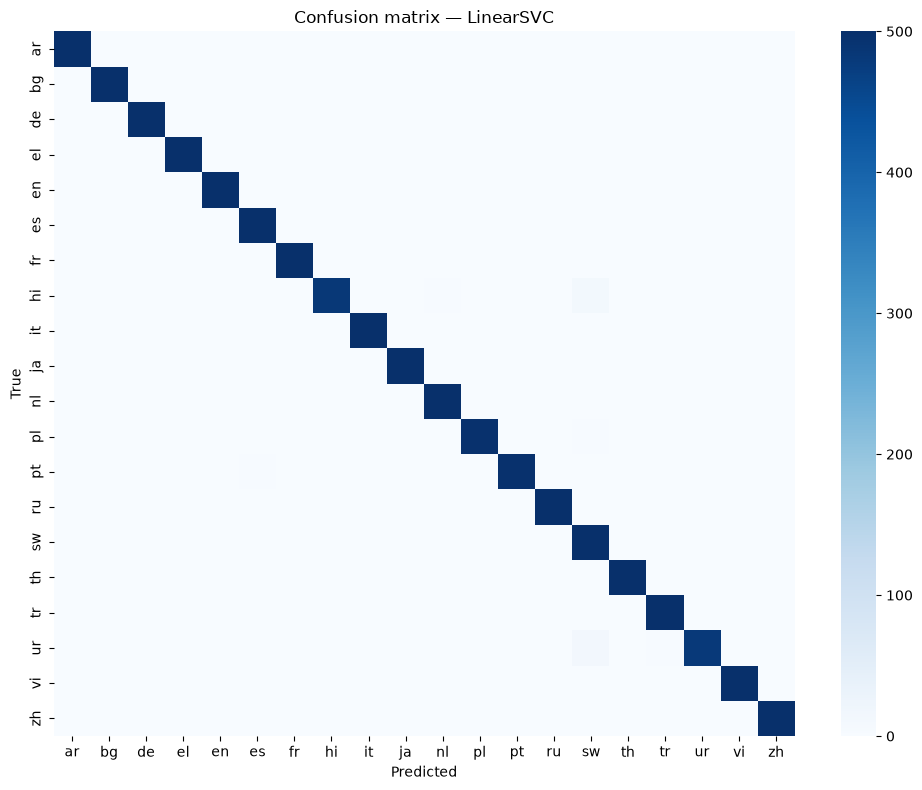

In [46]:
test_preds = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, test_preds))
print("Test macro-F1:", f1_score(y_test, test_preds, average="macro"))
print()
print(classification_report(y_test, test_preds))

cm = confusion_matrix(y_test, test_preds, labels=sorted(y_test.unique()))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()


## 8. Save the model artifacts

We persist the fitted vectorizer and the trained classifier separately with `joblib`, so the deployment
service (Flask/FastAPI, built in the final integration stage) can load them without retraining.


In [47]:
import os
os.makedirs("../artifacts", exist_ok=True)

joblib.dump(vectorizer, "../artifacts/lang_id_vectorizer.joblib")
joblib.dump(best_model, "../artifacts/lang_id_model.joblib")

print("Saved:")
print(" - ../artifacts/lang_id_vectorizer.joblib")
print(" - ../artifacts/lang_id_model.joblib")


Saved:
 - ../artifacts/lang_id_vectorizer.joblib
 - ../artifacts/lang_id_model.joblib


## 9. Inference helper

A small reusable function the rest of the pipeline (sentiment → intent → RAG) will call first on every incoming message.

In [48]:
def detect_language(text: str, vectorizer=vectorizer, model=best_model) -> str:
    """Return the ISO-639-1 language code predicted for a single customer message."""
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return model.predict(vec)[0]

# Quick manual sanity checks
for sample in [
    "Hello, where is my order?",
    "Bonjour, où est ma commande ?",
    "Hola, ¿dónde está mi pedido?",
    "مرحبا، فين طلبي؟",
]:
    print(f"{sample!r:45s} -> {detect_language(sample)}")


'Hello, where is my order?'                   -> en
'Bonjour, où est ma commande ?'               -> fr
'Hola, ¿dónde está mi pedido?'                -> pt
'مرحبا، فين طلبي؟'                            -> ar
